In [1]:
import copy
from IPython.display import display, Image
import logging
import numpy
import os
import pandas
import pdb
import plotly
import pprint
import pyarrow
import pyarrow.parquet as pq
import six
import sys
import time

import CS230

In [2]:
plotly.offline.init_notebook_mode(connected=True)

In [3]:
logger = CS230.common.get_logger(level=logging.INFO)

In [4]:
file_paths = CS230.data.get_all_file_paths()
logger.debug(file_paths)

In [5]:
stride = 1

image_paths = []

for file_path in file_paths:
    df = CS230.data.load(file_path)
    df = CS230.data.add_diffs(df, stride)
    df = CS230.data.clean_discontinuities(df, stride)
    
    fig = CS230.data.get_plotly_fig(df, file_path)
    
    #plotly.offline.iplot(fig)
    image_path = os.path.join('images', file_path.split('/')[-2], 'diff_' + os.path.splitext(file_path.split('/')[-1])[0] + '.jpeg')
    dir_name = os.path.join('images', file_path.split('/')[-2])    
    if not os.path.exists(dir_name):
        os.mkdir(dir_name)
    
    plotly.io.write_image(fig, image_path)
    logger.info('wrote image file: %s', image_path)
    image_paths.append(image_path)
    
    del df

00-45-45 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/diff_20130810_01_01_01_grandsport.jpeg
00-45-47 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/diff_20130810_02_01_01_grandsport.jpeg
00-45-47 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/diff_20130811_01_01_01_grandsport.jpeg
00-45-49 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/diff_20130811_02_01_01_grandsport.jpeg
00-45-50 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/diff_20130815_01_01_02_grandsport.jpeg
00-45-51 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/diff_20130816_01_01_02_grandsport.jpeg
00-45-53 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/diff_20130817_01_01_02_grandsport.jpeg
00-45-54 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/diff_20130817_02_01_02_grandsport.jpeg
00-45-54 | INFO | wrote image file: images/2013_Targa_Sixty-Six/diff_201

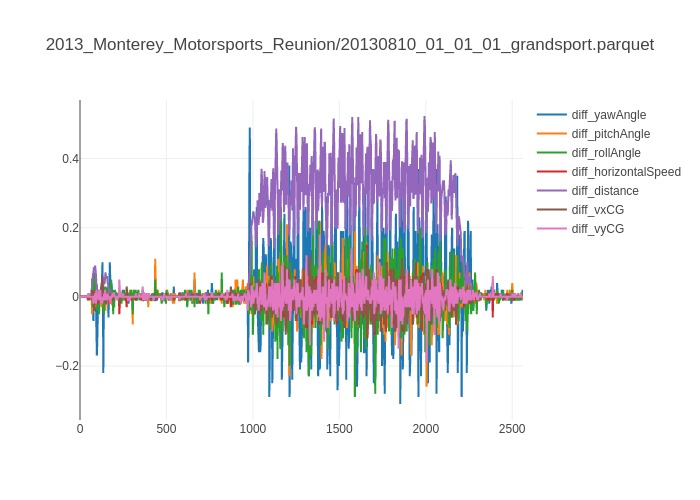

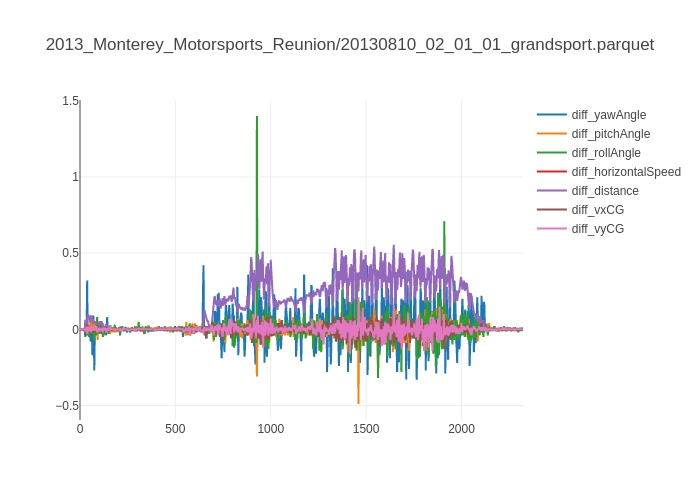

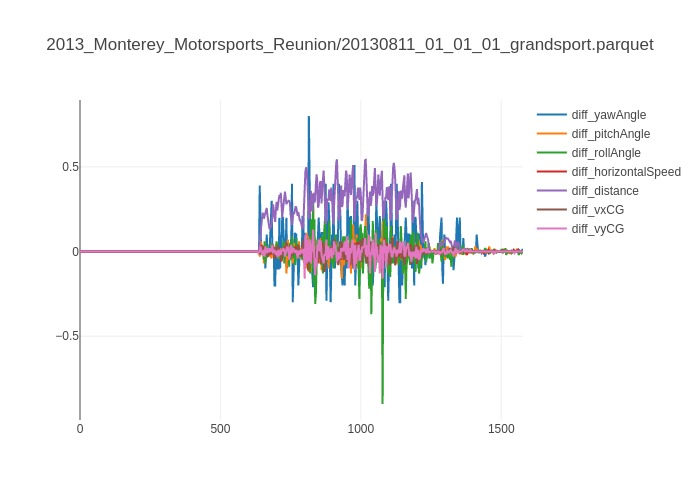

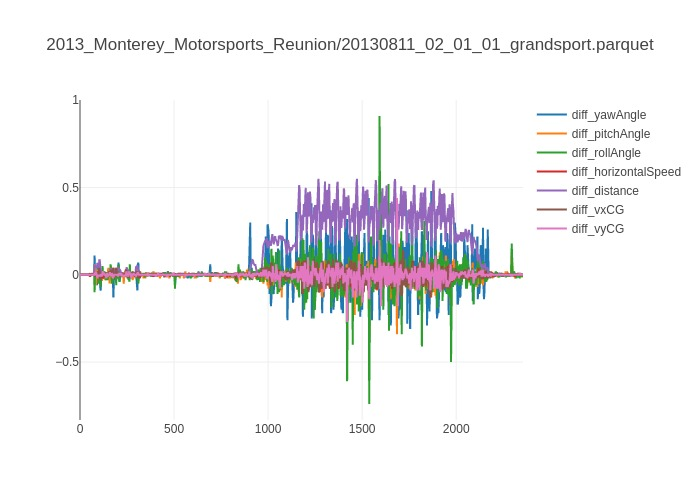

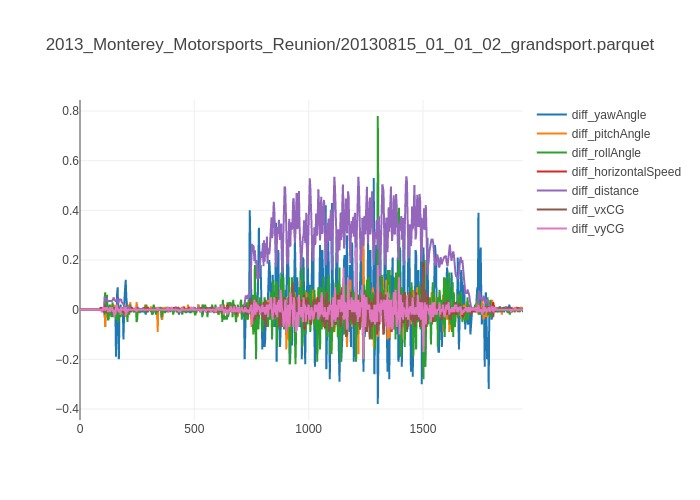

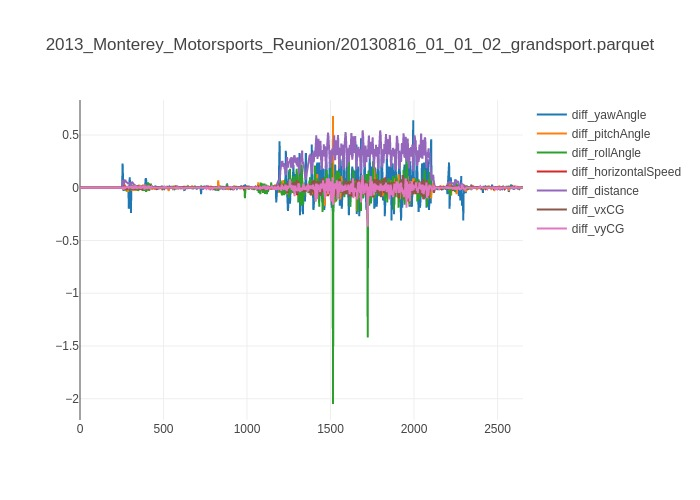

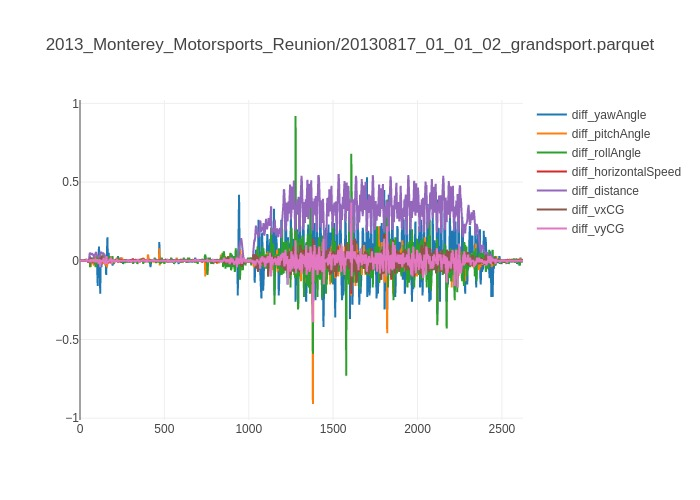

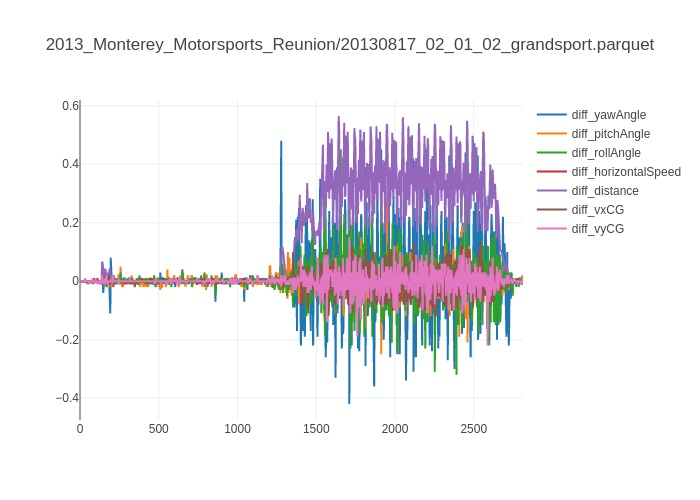

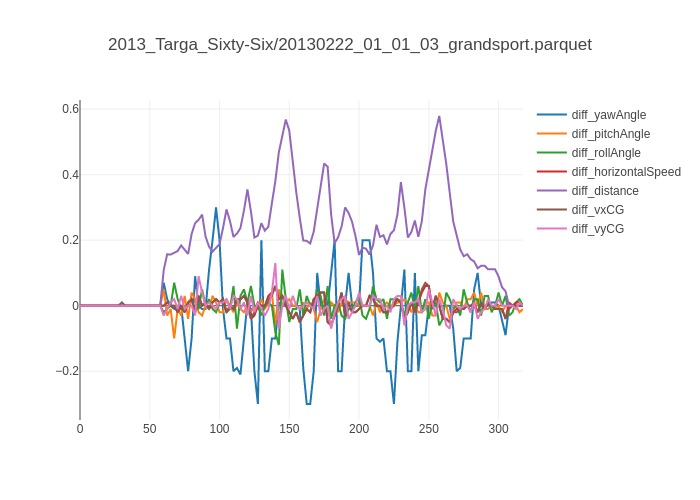

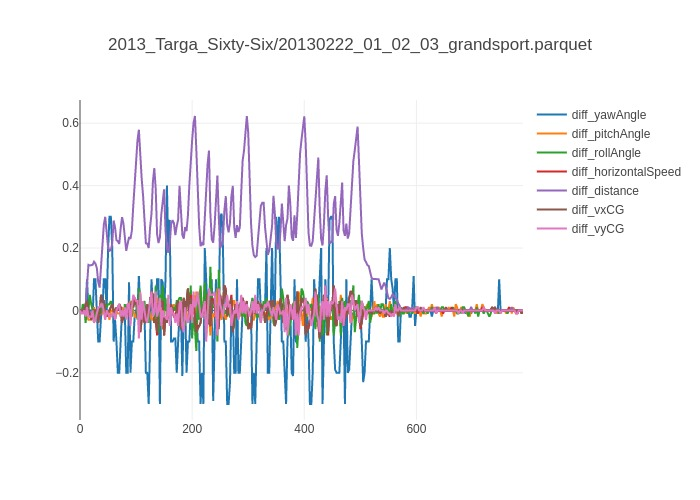

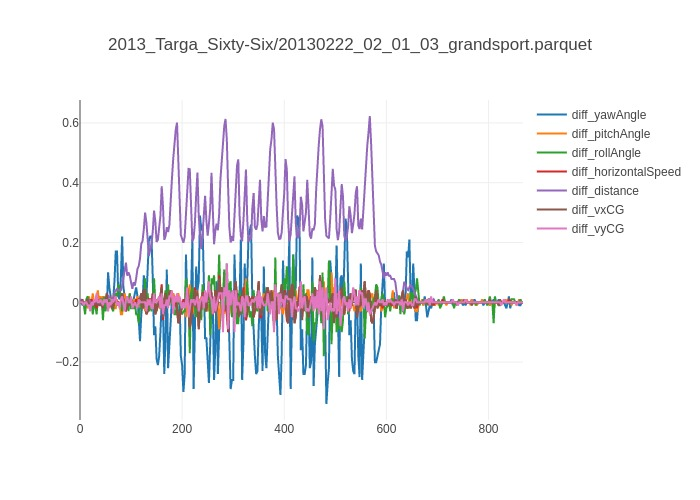

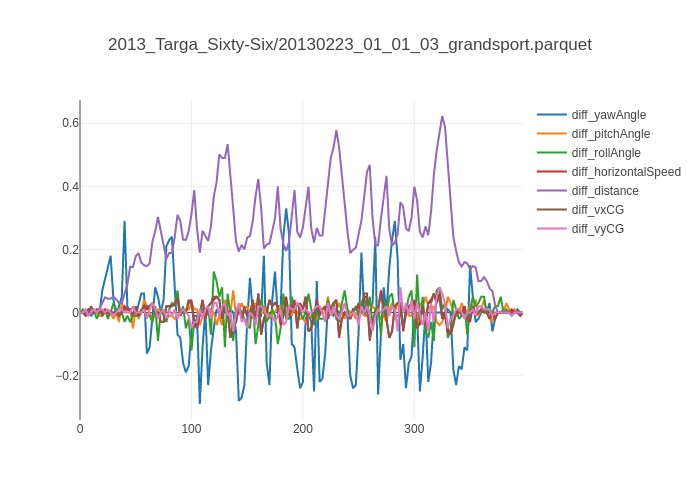

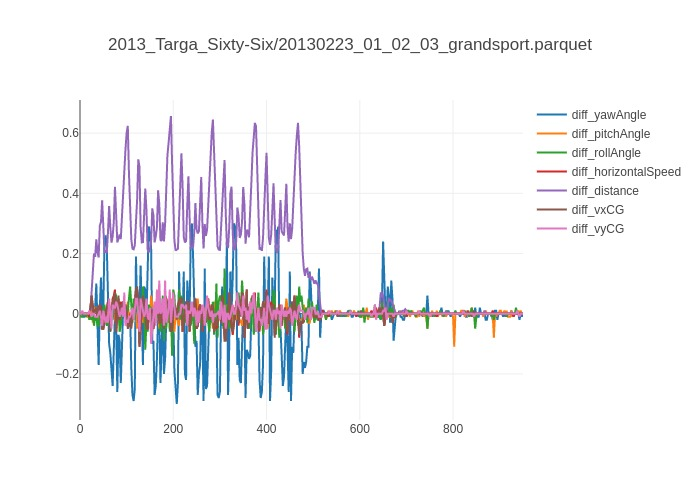

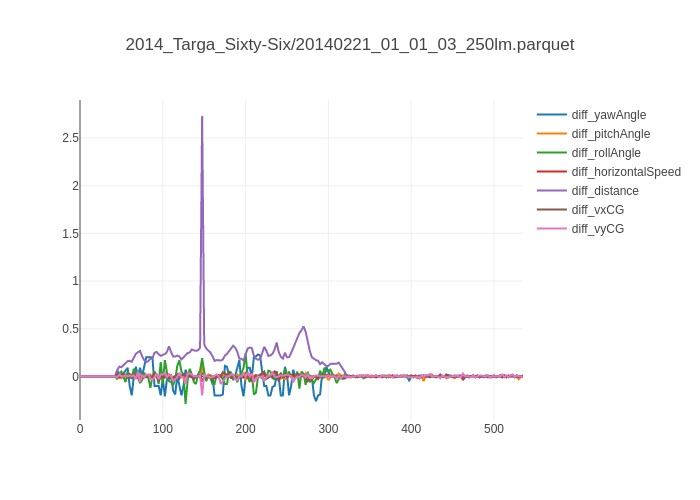

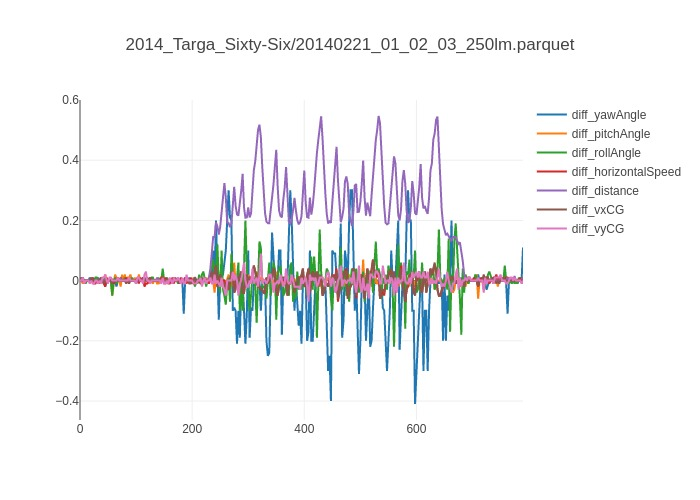

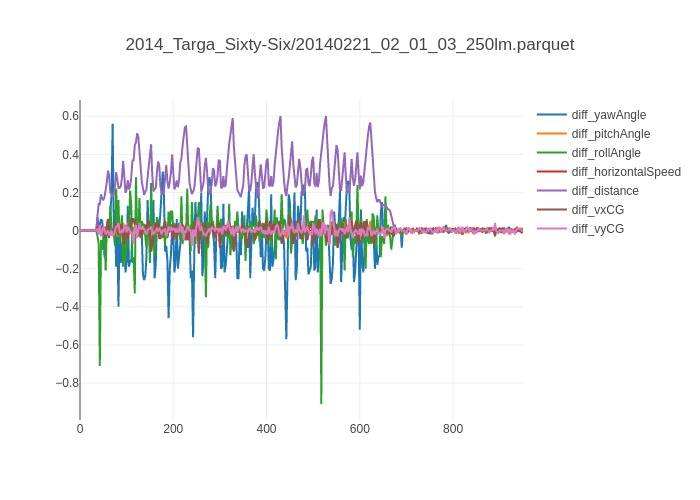

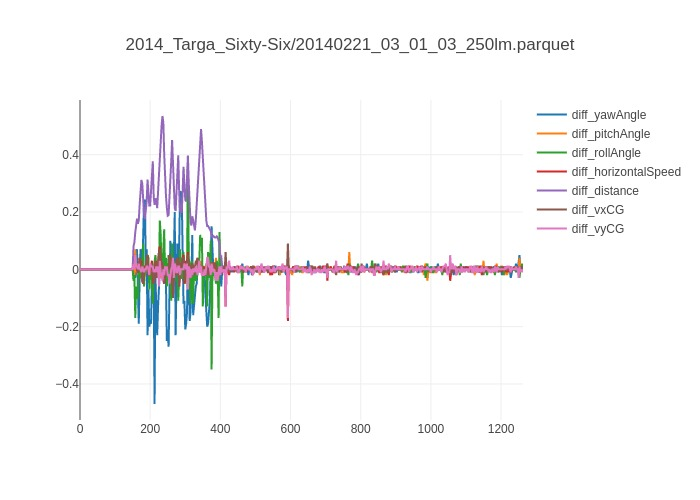

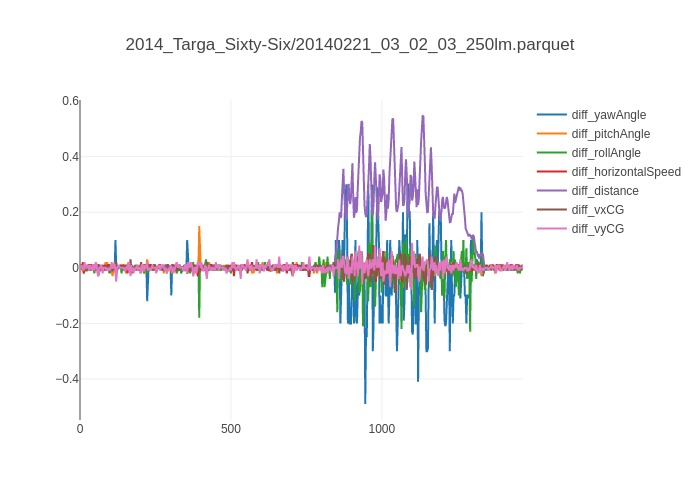

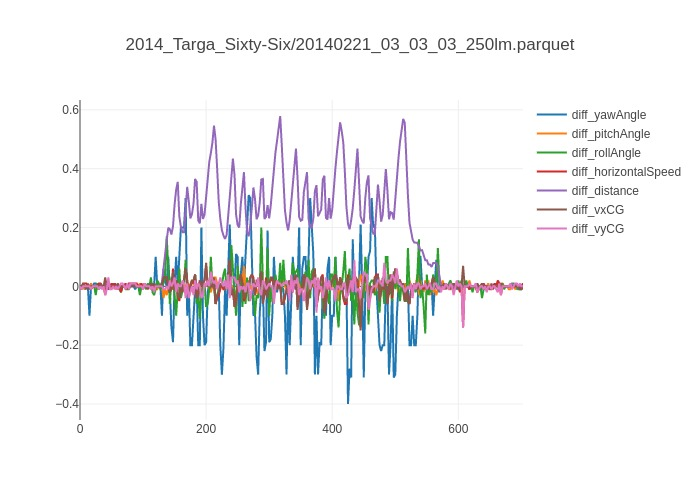

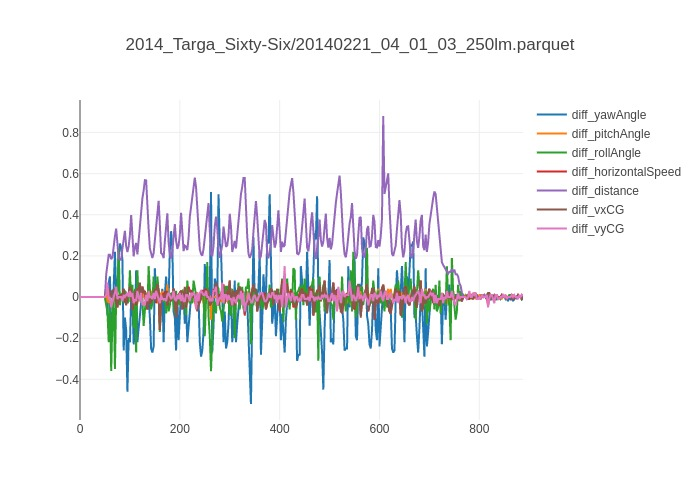

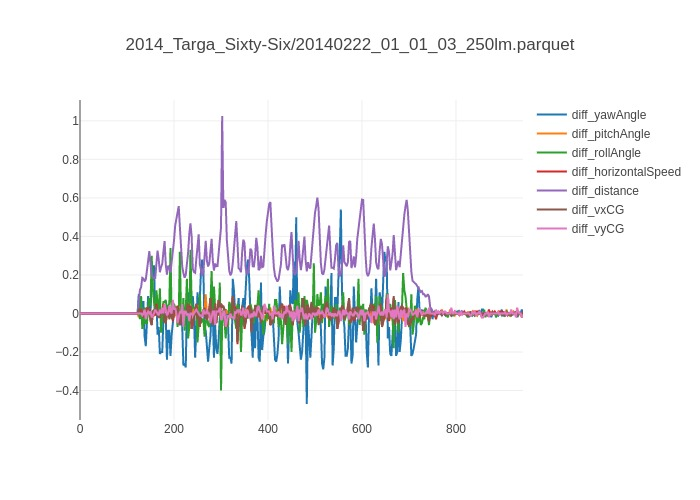

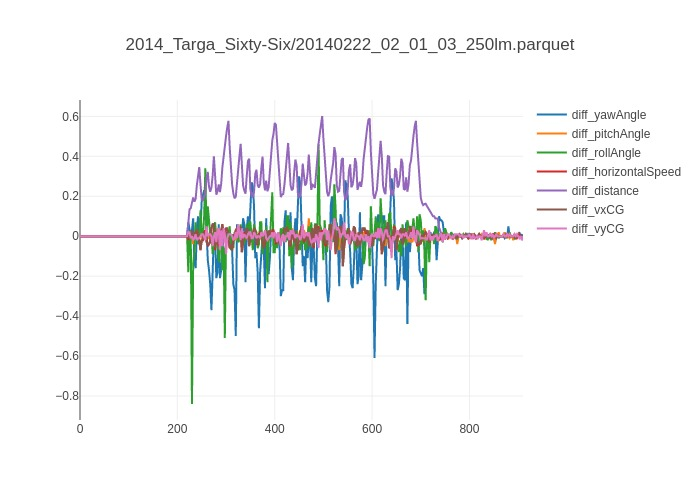

In [6]:
for image_path in image_paths:
    display(Image(filename=image_path))